In [1]:
#%pip install lifelines pandas numpy matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import (
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
    GeneralizedGammaRegressionFitter
)

from lifelines.utils import concordance_index
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_context("notebook")

In [3]:
# Change the path only if your file name/location is different.
DATA_PATH = "telco.csv"

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())
display(df_raw.describe(include="all"))

Dataset shape: (1000, 15)


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        1000 non-null   int64 
 1   region    1000 non-null   object
 2   tenure    1000 non-null   int64 
 3   age       1000 non-null   int64 
 4   marital   1000 non-null   object
 5   address   1000 non-null   int64 
 6   income    1000 non-null   int64 
 7   ed        1000 non-null   object
 8   retire    1000 non-null   object
 9   gender    1000 non-null   object
 10  voice     1000 non-null   object
 11  internet  1000 non-null   object
 12  forward   1000 non-null   object
 13  custcat   1000 non-null   object
 14  churn     1000 non-null   object
dtypes: int64(5), object(10)
memory usage: 117.3+ KB


None

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
count,1000.000000,1000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000,1000,1000,1000,1000,1000,1000,1000
unique,NaN,3,NaN,NaN,2,NaN,NaN,5,2,2,2,2,2,4,2
top,NaN,Zone 3,NaN,NaN,Unmarried,NaN,NaN,High school degree,No,Female,No,No,No,Plus service,No
freq,NaN,344,NaN,NaN,505,NaN,NaN,287,953,517,696,632,507,281,726
mean,500.500000,NaN,35.526000,41.684000,NaN,11.551000,77.535000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,288.819436,NaN,21.359812,12.558816,NaN,10.086681,107.044165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,1.000000,18.000000,NaN,0.000000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,250.750000,NaN,17.000000,32.000000,NaN,3.000000,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,500.500000,NaN,34.000000,40.000000,NaN,9.000000,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,750.250000,NaN,54.000000,51.000000,NaN,18.000000,83.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Survival analysis setup:
# duration_col = tenure
# event_col = churn_event, where 1 = churn happened, 0 = censored / still active

df = df_raw.copy()

df["churn_event"] = df["churn"].map({"Yes": 1, "No": 0}).astype(int)

print("Churn distribution:")
display(df["churn"].value_counts())
display(df["churn_event"].value_counts(normalize=True).rename("proportion"))

Churn distribution:


churn
No     726
Yes    274
Name: count, dtype: int64

churn_event
0    0.726
1    0.274
Name: proportion, dtype: float64

In [5]:
# We drop ID because it is only an identifier.
# We also drop the original churn text column because we created churn_event.

duration_col = "tenure"
event_col = "churn_event"

drop_cols = ["ID", "churn"]
df_model_base = df.drop(columns=drop_cols)

# One-hot encode categorical variables.
df_model = pd.get_dummies(df_model_base, drop_first=True)

# Make sure all columns are numeric.
df_model = df_model.apply(pd.to_numeric)

print("Modeling dataset shape:", df_model.shape)
display(df_model.head())
display(df_model.columns)

Modeling dataset shape: (1000, 20)


,tenure,age,address,income,churn_event,region_Zone 2,region_Zone 3,marital_Unmarried,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,retire_Yes,gender_Male,voice_Yes,internet_Yes,forward_Yes,custcat_E-service,custcat_Plus service,custcat_Total service
0,13,44,9,64,1,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,11,33,7,136,1,False,True,False,False,False,True,False,False,True,True,False,True,False,False,True
2,68,52,24,116,0,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False
3,33,33,12,33,1,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False
4,23,30,9,30,0,True,False,False,True,False,False,False,False,True,False,False,True,False,True,False


Index(['tenure', 'age', 'address', 'income', 'churn_event', 'region_Zone 2', 'region_Zone 3', 'marital_Unmarried',
       'ed_Did not complete high school', 'ed_High school degree', 'ed_Post-undergraduate degree', 'ed_Some college',
       'retire_Yes', 'gender_Male', 'voice_Yes', 'internet_Yes', 'forward_Yes', 'custcat_E-service',
       'custcat_Plus service', 'custcat_Total service'],
      dtype='object')

In [6]:
aft_models = {
    "Weibull AFT": WeibullAFTFitter(penalizer=0.01),
    "Log-Normal AFT": LogNormalAFTFitter(penalizer=0.01),
    "Log-Logistic AFT": LogLogisticAFTFitter(penalizer=0.01),
    "Generalized Gamma Regression": GeneralizedGammaRegressionFitter(penalizer=0.01)
}

fitted_models = {}

for name, model in aft_models.items():
    print(f"\nFitting {name}...")
    try:
        model.fit(
            df_model,
            duration_col=duration_col,
            event_col=event_col
        )
        fitted_models[name] = model
        print(f"{name} fitted successfully.")
    except Exception as e:
        print(f"{name} failed:")
        print(e)

print("\nSuccessfully fitted models:")
print(list(fitted_models.keys()))


Fitting Weibull AFT...
Weibull AFT fitted successfully.

Fitting Log-Normal AFT...
Log-Normal AFT fitted successfully.

Fitting Log-Logistic AFT...
Log-Logistic AFT fitted successfully.

Fitting Generalized Gamma Regression...
Generalized Gamma Regression failed:

               Fitting did not converge. Try the following:

               0. Are there any lifelines warnings outputted during the `fit`?
               1. Inspect your DataFrame: does everything look as expected?
               2. Try scaling your duration vector down, i.e. `df[duration_col] = df[duration_col]/100`
               3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
               4. Try using an alternate minimizer: ``fitter._scipy_fit_method = "SLSQP"``.
               5. Trying adding a small penalizer (or changing it, if already present). Example: `GeneralizedGammaRegressionFitter(penalizer=0.01).fit(...)`.
               6. Are there 

In [7]:
def safe_predict_median(model, X):
    """
    Predict median survival time.
    Replace infinite values with a large finite value so concordance can be computed.
    """
    pred = model.predict_median(X)
    pred = pd.Series(pred).replace([np.inf, -np.inf], np.nan)

    if pred.isna().all():
        pred = pd.Series(np.repeat(df_model[duration_col].max(), len(X)))
    else:
        pred = pred.fillna(pred.max())

    return pred


X_all = df_model.drop(columns=[duration_col, event_col])
T = df_model[duration_col]
E = df_model[event_col]

comparison_rows = []

for name, model in fitted_models.items():
    try:
        log_lik = model.log_likelihood_
        k = len(model.params_)
        n = df_model.shape[0]

        aic = model.AIC_
        bic = -2 * log_lik + np.log(n) * k

        predicted_median = safe_predict_median(model, X_all)

        # Larger predicted median survival should mean longer survival.
        c_index = concordance_index(T, predicted_median, E)

        comparison_rows.append({
            "Model": name,
            "Log-Likelihood": log_lik,
            "Num Parameters": k,
            "AIC": aic,
            "BIC": bic,
            "Concordance Index": c_index
        })

    except Exception as e:
        print(f"Could not compare {name}: {e}")

comparison_df = pd.DataFrame(comparison_rows).sort_values("AIC")
display(comparison_df)

best_model_name = comparison_df.iloc[0]["Model"]
best_full_model = fitted_models[best_model_name]

print(f"Best model by AIC: {best_model_name}")

,Model,Log-Likelihood,Num Parameters,AIC,BIC,Concordance Index
1,Log-Normal AFT,-1463.221455,20,2966.442911,3064.598017,0.786336
2,Log-Logistic AFT,-1464.263153,20,2968.526305,3066.681411,0.786363
0,Weibull AFT,-1467.074513,20,2974.149025,3072.304131,0.783367


Best model by AIC: Log-Normal AFT


In [8]:
for name, model in fitted_models.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    model.print_summary()


Weibull AFT


<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn_event'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.07
         time fit was run = 2026-05-10 12:59:08 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                        
lambda_ address                          0.04      1.04      0.01            0.02            0.06                1.02                1.06
        age                              0.03      1.03      0.01            0.01            0.04                1.01                1.04
        custcat_E-service                0.90      2.45      0.15            0.60            1.19                1.83                3.29
        custcat_Plus service             0.66      1.93      0.18            0.30            1.01                1.35                2.74
        custcat_Total service            0.85      2.35      0.20            0.46            1.24                1.59                3.46
        ed_Did not complete high school  0.41      1.50      0.18            0.04            0.77                1.04                2.15
        ed_High school degree            0.30      1.34      0.14            0.02            0.57                1.02                1.77
        ed_Post-undergraduate degree     0.18      1.20      0.19           -0.18            0.55                0.83                1.73
        ed_Some college                  0.23      1.26      0.14           -0.05            0.50                0.95                1.65
        forward_Yes                     -0.06      0.95      0.14           -0.33            0.22                0.72                1.25
        gender_Male                      0.00      1.00      0.10           -0.19            0.20                0.82                1.22
        income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        internet_Yes                    -0.73      0.48      0.13           -0.99           -0.47                0.37                0.62
        marital_Unmarried               -0.34      0.71      0.10           -0.54           -0.14                0.58                0.87
        region_Zone 2                   -0.06      0.94      0.12           -0.30            0.18                0.74                1.20
        region_Zone 3                    0.11      1.12      0.12           -0.13            0.35                0.88                1.42
        retire_Yes                       0.19      1.21      0.48           -0.75            1.14                0.47                3.12
        voice_Yes                       -0.29      0.75      0.14           -0.57           -0.01                0.57                0.99
        Intercept                        2.84     17.14      0.26            2.33            3.35               10.28               28.58
rho_    Intercept                        0.18      1.20      0.05            0.09            0.28                1.09                1.32

                                         cmp to     z      p  -log2(p)
param   covariate                                                     
lambda_ address                            0.00  4.82 <0.005     19.41
        age                                0.00  4.28 <0.005     15.71
        custcat_E-service                  0.00  6.00 <0.005     28.92
        custcat_Plus service               0.00  3.64 <0.005     11.82
        custcat_Total service              0.00  4.29 <0.005     15.79
        ed_Did not complete high school    0.00  2.19   0.03      5.15
        ed_High school de


Log-Normal AFT


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn_event'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1463.22
         time fit was run = 2026-05-10 12:59:08 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
mu_    address                          0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                              0.03      1.03      0.01            0.02            0.04                1.02                1.05
       custcat_E-service                0.97      2.63      0.16            0.65            1.28                1.92                3.61
       custcat_Plus service             0.78      2.18      0.20            0.40            1.17                1.49                3.21
       custcat_Total service            0.98      2.66      0.23            0.54            1.42                1.71                4.15
       ed_Did not complete high school  0.34      1.40      0.19           -0.03            0.71                0.97                2.04
       ed_High school degree            0.29      1.33      0.15           -0.02            0.59                0.98                1.80
       ed_Post-undergraduate degree    -0.05      0.95      0.22           -0.47            0.37                0.62                1.45
       ed_Some college                  0.24      1.27      0.16           -0.07            0.55                0.93                1.73
       forward_Yes                     -0.11      0.90      0.17           -0.43            0.22                0.65                1.24
       gender_Male                      0.05      1.05      0.11           -0.17            0.26                0.84                1.30
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.73      0.48      0.14           -0.99           -0.46                0.37                0.63
       marital_Unmarried               -0.44      0.64      0.11           -0.66           -0.22                0.52                0.80
       region_Zone 2                   -0.09      0.91      0.14           -0.36            0.18                0.70                1.19
       region_Zone 3                    0.04      1.04      0.14           -0.23            0.30                0.80                1.36
       retire_Yes                       0.05      1.05      0.41           -0.76            0.86                0.47                2.37
       voice_Yes                       -0.37      0.69      0.16           -0.68           -0.06                0.50                0.94
       Intercept                        2.44     11.44      0.28            1.89            2.98                6.63               19.74
sigma_ Intercept                        0.26      1.30      0.04            0.17            0.35                1.19                1.42

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
mu_    address                            0.00  4.97 <0.005     20.52
       age                                0.00  4.72 <0.005     18.71
       custcat_E-service                  0.00  5.98 <0.005     28.73
       custcat_Plus service               0.00  3.98 <0.005     13.84
       custcat_Total service              0.00  4.33 <0.005     16.07
       ed_Did not complete high school    0.00  1.79   0.07      3.77
       ed_High school degree              0.00  1.86 


Log-Logistic AFT


<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn_event'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1464.26
         time fit was run = 2026-05-10 12:59:09 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
alpha_ address                          0.04      1.04      0.01            0.02            0.05                1.02                1.06
       age                              0.03      1.03      0.01            0.02            0.04                1.02                1.05
       custcat_E-service                0.94      2.57      0.16            0.63            1.25                1.88                3.50
       custcat_Plus service             0.74      2.09      0.19            0.36            1.11                1.43                3.05
       custcat_Total service            1.00      2.71      0.22            0.56            1.43                1.76                4.17
       ed_Did not complete high school  0.40      1.49      0.19            0.03            0.77                1.03                2.16
       ed_High school degree            0.31      1.36      0.15            0.02            0.60                1.02                1.82
       ed_Post-undergraduate degree    -0.04      0.96      0.21           -0.45            0.37                0.64                1.45
       ed_Some college                  0.21      1.23      0.15           -0.09            0.50                0.92                1.65
       forward_Yes                     -0.11      0.89      0.16           -0.43            0.20                0.65                1.22
       gender_Male                      0.03      1.03      0.11           -0.18            0.24                0.84                1.28
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.75      0.47      0.14           -1.02           -0.48                0.36                0.62
       marital_Unmarried               -0.43      0.65      0.11           -0.64           -0.22                0.53                0.80
       region_Zone 2                   -0.05      0.95      0.13           -0.30            0.21                0.74                1.23
       region_Zone 3                    0.10      1.11      0.13           -0.15            0.36                0.86                1.44
       retire_Yes                       0.10      1.10      0.45           -0.78            0.98                0.46                2.65
       voice_Yes                       -0.34      0.71      0.16           -0.65           -0.04                0.52                0.96
       Intercept                        2.42     11.29      0.27            1.89            2.95                6.64               19.18
beta_  Intercept                        0.34      1.41      0.05            0.24            0.44                1.27                1.55

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
alpha_ address                            0.00  4.57 <0.005     17.64
       age                                0.00  4.81 <0.005     19.34
       custcat_E-service                  0.00  5.97 <0.005     28.68
       custcat_Plus service               0.00  3.82 <0.005     12.86
       custcat_Total service              0.00  4.52 <0.005     17.33
       ed_Did not complete high school    0.00  2.11   0.03      4.85
       ed_High school degree              0.00  2.0

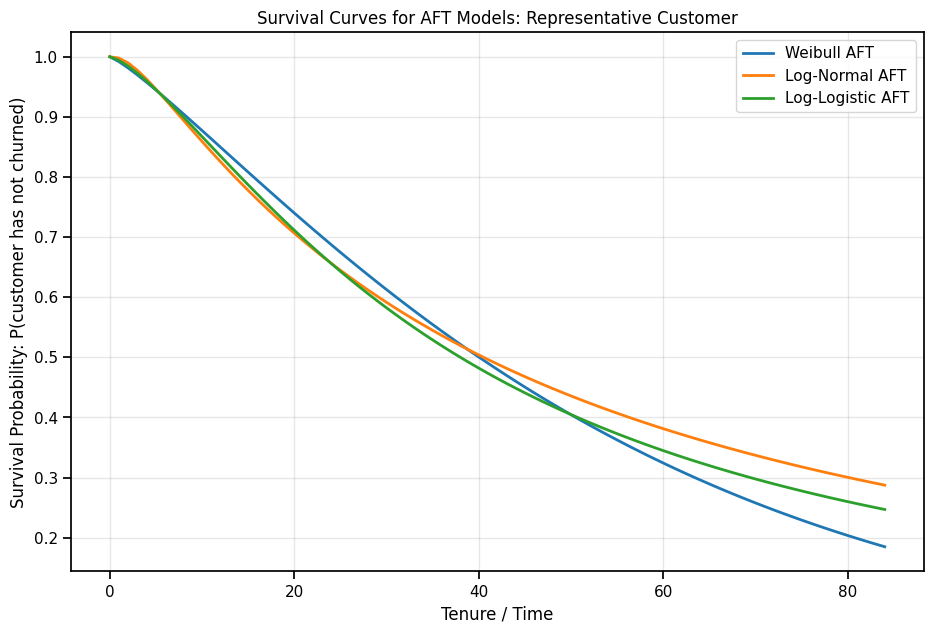

In [9]:
# Representative customer profile:
# For numeric/encoded variables, median gives a reasonable central profile.
representative_customer = X_all.median().to_frame().T

times = np.arange(0, int(df_model[duration_col].max()) + 13)

plt.figure(figsize=(11, 7))

for name, model in fitted_models.items():
    try:
        sf = model.predict_survival_function(representative_customer, times=times)
        plt.plot(sf.index, sf.iloc[:, 0], label=name, linewidth=2)
    except Exception as e:
        print(f"Could not plot {name}: {e}")

plt.title("Survival Curves for AFT Models: Representative Customer")
plt.xlabel("Tenure / Time")
plt.ylabel("Survival Probability: P(customer has not churned)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
summary = best_full_model.summary.reset_index()

display(summary)

# Identify the main location parameter depending on model type.
# Weibull uses lambda_, Log-Normal uses mu_, Log-Logistic uses alpha_,
# Generalized Gamma usually includes mu_ as the location parameter.
possible_main_params = ["lambda_", "mu_", "alpha_"]

available_params = summary["param"].unique().tolist()
main_param = None

for p in possible_main_params:
    if p in available_params:
        main_param = p
        break

if main_param is None:
    main_param = available_params[0]

print("Using main parameter for feature significance:", main_param)

significant_summary = summary[
    (summary["param"] == main_param) &
    (summary["covariate"] != "Intercept") &
    (summary["p"] < 0.05)
].copy()

significant_summary = significant_summary.sort_values("p")

print("Significant features:")
display(significant_summary[["param", "covariate", "coef", "exp(coef)", "p"]])

significant_features = significant_summary["covariate"].tolist()

if len(significant_features) == 0:
    print("No significant features found at p < 0.05. Using full model as final model.")
    final_features = list(X_all.columns)
else:
    final_features = significant_features

print("Final features:")
print(final_features)

,param,covariate,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
0,mu_,address,0.041296,1.042160,0.008307,0.025015,0.057576,1.025331,1.059266,0.0,4.971489,6.644069e-07,20.521430
1,mu_,age,0.031743,1.032252,0.006722,0.018569,0.044917,1.018742,1.045941,0.0,4.722544,2.329129e-06,18.711778
2,mu_,custcat_E-service,0.966644,2.629107,0.161671,0.649776,1.283513,1.915111,3.609298,0.0,5.979093,2.243831e-09,28.731389
3,mu_,custcat_Plus service,0.780727,2.183058,0.196069,0.396439,1.165014,1.486522,3.205968,0.0,3.981905,6.836501e-05,13.836382
4,mu_,custcat_Total service,0.979244,2.662442,0.225900,0.536487,1.422000,1.709990,4.145404,0.0,4.334849,1.458600e-05,16.065057
5,mu_,ed_Did not complete high school,0.339153,1.403759,0.189488,-0.032235,0.710542,0.968279,2.035094,0.0,1.789846,7.347875e-02,3.766529
6,mu_,ed_High school degree,0.286579,1.331864,0.154231,-0.015708,0.588866,0.984415,1.801944,0.0,1.858119,6.315216e-02,3.985024
7,mu_,ed_Post-undergraduate degree,-0.050229,0.951012,0.215654,-0.472904,0.372446,0.623190,1.451280,0.0,-0.232914,8.158283e-01,0.293663
8,mu_,ed_Some college,0.239899,1.271121,0.157363,-0.068527,0.548325,0.933769,1.730351,0.0,1.524496,1.273850e-01,2.972733
9,mu_,forward_Yes,-0.108136,0.897506,0.165628,-0.432761,0.216490,0.648715,1.241711,0.0,-0.652881,5.138331e-01,0.960628


Using main parameter for feature significance: mu_
Significant features:


,param,covariate,coef,exp(coef),p
2,mu_,custcat_E-service,0.966644,2.629107,2.243831e-09
12,mu_,internet_Yes,-0.725240,0.484208,1.110941e-07
0,mu_,address,0.041296,1.042160,6.644069e-07
1,mu_,age,0.031743,1.032252,2.329129e-06
4,mu_,custcat_Total service,0.979244,2.662442,1.458600e-05
3,mu_,custcat_Plus service,0.780727,2.183058,6.836501e-05
13,mu_,marital_Unmarried,-0.442529,0.642409,7.263414e-05
17,mu_,voice_Yes,-0.372184,0.689228,1.966379e-02


Final features:
['custcat_E-service', 'internet_Yes', 'address', 'age', 'custcat_Total service', 'custcat_Plus service', 'marital_Unmarried', 'voice_Yes']


In [11]:
final_df_model = df_model[[duration_col, event_col] + final_features].copy()

# Use same model family as the best AIC model.
final_model_class = type(best_full_model)
final_model = final_model_class(penalizer=0.01)

final_model.fit(
    final_df_model,
    duration_col=duration_col,
    event_col=event_col
)

print("Final model:", best_model_name)
final_model.print_summary()

Final model: Log-Normal AFT


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn_event'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.87
         time fit was run = 2026-05-10 12:59:42 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      0.93      2.54      0.16            0.62            1.25                1.86                3.48
       custcat_Plus service   0.75      2.11      0.16            0.43            1.06                1.54                2.89
       custcat_Total service  0.87      2.40      0.19            0.49            1.26                1.64                3.51
       internet_Yes          -0.79      0.45      0.13           -1.05           -0.53                0.35                0.59
       marital_Unmarried     -0.44      0.65      0.11           -0.65           -0.22                0.52                0.80
       voice_Yes             -0.40      0.67      0.16           -0.71           -0.09                0.49                0.91
       Intercept              2.59     13.35      0.23            2.13            3.05                8.45               21.08
sigma_ Intercept              0.27      1.31      0.04            0.18            0.36                1.20                1.43

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  5.06 <0.005     21.20
       age                      0.00  5.93 <0.005     28.33
       custcat_E-service        0.00  5.81 <0.005     27.28
       custcat_Plus service     0.00  4.67 <0.005     18.34
       custcat_Total service    0.00  4.48 <0.005     17.06
       internet_Yes             0.00 -5.99 <0.005     28.86
       marital_Unmarried        0.00 -3.94 <0.005     13.56
       voice_Yes                0.00 -2.54   0.01      6.48
       Intercept                0.00 11.12 <0.005     93.00
sigma_ Intercept                0.00  6.02 <0.005     29.06
---
Concordance = 0.78
AIC = 2955.75
log-likelihood ratio test = 269.29 on 8 df
-log2(p) of ll-ratio test = 175.58

In [12]:
X_final = final_df_model.drop(columns=[duration_col, event_col])
T_final = final_df_model[duration_col]
E_final = final_df_model[event_col]

final_pred_median = safe_predict_median(final_model, X_final)

final_comparison = pd.DataFrame([
    {
        "Model": f"{best_model_name} full",
        "AIC": best_full_model.AIC_,
        "BIC": -2 * best_full_model.log_likelihood_ + np.log(df_model.shape[0]) * len(best_full_model.params_),
        "Concordance Index": concordance_index(T, safe_predict_median(best_full_model, X_all), E),
        "Num Features": X_all.shape[1]
    },
    {
        "Model": f"{best_model_name} significant-only final",
        "AIC": final_model.AIC_,
        "BIC": -2 * final_model.log_likelihood_ + np.log(final_df_model.shape[0]) * len(final_model.params_),
        "Concordance Index": concordance_index(T_final, final_pred_median, E_final),
        "Num Features": X_final.shape[1]
    }
])

display(final_comparison)

,Model,AIC,BIC,Concordance Index,Num Features
0,Log-Normal AFT full,2966.442911,3064.598017,0.786336,18
1,Log-Normal AFT significant-only final,2955.746600,3004.824153,0.781088,8


In [13]:
final_summary = final_model.summary.reset_index()

available_params_final = final_summary["param"].unique().tolist()
main_param_final = None

for p in possible_main_params:
    if p in available_params_final:
        main_param_final = p
        break

if main_param_final is None:
    main_param_final = available_params_final[0]

coef_table = final_summary[
    (final_summary["param"] == main_param_final) &
    (final_summary["covariate"] != "Intercept")
].copy()

coef_table["Effect on churn risk"] = np.where(
    coef_table["coef"] > 0,
    "Lowers churn risk / increases survival time",
    "Raises churn risk / decreases survival time"
)

coef_table = coef_table.sort_values("p")

display(coef_table[[
    "covariate", "coef", "exp(coef)", "p", "Effect on churn risk"
]])

,covariate,coef,exp(coef),p,Effect on churn risk
5,internet_Yes,-0.790409,0.453659,2.056054e-09,Raises churn risk / decreases survival time
1,age,0.035750,1.036397,2.970501e-09,Lowers churn risk / increases survival time
2,custcat_E-service,0.932215,2.540129,6.115240e-09,Lowers churn risk / increases survival time
0,address,0.041862,1.042750,4.140776e-07,Lowers churn risk / increases survival time
3,custcat_Plus service,0.747872,2.112499,3.018632e-06,Lowers churn risk / increases survival time
4,custcat_Total service,0.873575,2.395460,7.321265e-06,Lowers churn risk / increases survival time
6,marital_Unmarried,-0.435982,0.646629,8.301037e-05,Raises churn risk / decreases survival time
7,voice_Yes,-0.398478,0.671341,1.123341e-02,Raises churn risk / decreases survival time


In [14]:
# Business assumptions for CLV.
# Replace these values if your lecturer gave exact ARPU / monthly revenue in the slides.

monthly_revenue_by_custcat = {
    "Basic service": 25,
    "E-service": 35,
    "Plus service": 45,
    "Total service": 60
}

GROSS_MARGIN_RATE = 0.65
ANNUAL_DISCOUNT_RATE = 0.10
MONTHLY_DISCOUNT_RATE = (1 + ANNUAL_DISCOUNT_RATE) ** (1 / 12) - 1

CLV_HORIZON_MONTHS = 60

df_clv = df.copy()

df_clv["monthly_revenue"] = df_clv["custcat"].map(monthly_revenue_by_custcat)
df_clv["monthly_margin"] = df_clv["monthly_revenue"] * GROSS_MARGIN_RATE

display(df_clv[["ID", "custcat", "monthly_revenue", "monthly_margin"]].head())

,ID,custcat,monthly_revenue,monthly_margin
0,1,Basic service,25,16.25
1,2,Total service,60,39.00
2,3,Plus service,45,29.25
3,4,Basic service,25,16.25
4,5,Plus service,45,29.25


In [15]:
def conditional_survival_matrix(model, X, current_tenure, horizon_months):
    """
    Returns an n_customers x horizon_months matrix:
    P(survive to tenure + h | survived to current tenure)
    """
    current_tenure = pd.Series(current_tenure).astype(int).values
    n = len(current_tenure)

    max_time = int(current_tenure.max() + horizon_months)
    times_grid = np.arange(0, max_time + 1)

    sf = model.predict_survival_function(X, times=times_grid)
    sf_values = sf.values

    customer_idx = np.arange(n)

    S_current = sf_values[current_tenure, customer_idx]
    S_current = np.clip(S_current, 1e-8, 1)

    conditional_survival = []

    for h in range(1, horizon_months + 1):
        S_future = sf_values[current_tenure + h, customer_idx]
        cond_s = S_future / S_current
        cond_s = np.clip(cond_s, 0, 1)
        conditional_survival.append(cond_s)

    conditional_survival = np.vstack(conditional_survival).T

    return conditional_survival


X_final_customers = final_df_model.drop(columns=[duration_col, event_col])
current_tenure = final_df_model[duration_col]

cond_survival_60 = conditional_survival_matrix(
    final_model,
    X_final_customers,
    current_tenure=current_tenure,
    horizon_months=CLV_HORIZON_MONTHS
)

discount_factors_60 = np.array([
    1 / ((1 + MONTHLY_DISCOUNT_RATE) ** h)
    for h in range(1, CLV_HORIZON_MONTHS + 1)
])

monthly_margin = df_clv["monthly_margin"].values

clv_60 = (cond_survival_60 * discount_factors_60 * monthly_margin.reshape(-1, 1)).sum(axis=1)

df_clv["CLV_60_months"] = clv_60

display(df_clv[[
    "ID", "tenure", "churn", "custcat", "monthly_margin", "CLV_60_months"
]].head())

print("Average 60-month CLV:", df_clv["CLV_60_months"].mean())

,ID,tenure,churn,custcat,monthly_margin,CLV_60_months
0,1,13,Yes,Basic service,16.25,617.016267
1,2,11,Yes,Total service,39.00,1481.256937
2,3,68,No,Plus service,29.25,1330.192205
3,4,33,Yes,Basic service,16.25,551.947480
4,5,23,No,Plus service,29.25,1162.671635


Average 60-month CLV: 999.0229865073874


In [16]:
HORIZON_12 = 12

cond_survival_12 = conditional_survival_matrix(
    final_model,
    X_final_customers,
    current_tenure=current_tenure,
    horizon_months=HORIZON_12
)

discount_factors_12 = np.array([
    1 / ((1 + MONTHLY_DISCOUNT_RATE) ** h)
    for h in range(1, HORIZON_12 + 1)
])

df_clv["survival_probability_12m"] = cond_survival_12[:, -1]
df_clv["churn_risk_12m"] = 1 - df_clv["survival_probability_12m"]

clv_12 = (cond_survival_12 * discount_factors_12 * monthly_margin.reshape(-1, 1)).sum(axis=1)
df_clv["CLV_12_months"] = clv_12

display(df_clv[[
    "ID", "tenure", "churn", "custcat",
    "survival_probability_12m", "churn_risk_12m",
    "CLV_12_months", "CLV_60_months"
]].head())

display(df_clv[[
    "survival_probability_12m", "churn_risk_12m",
    "CLV_12_months", "CLV_60_months"
]].describe())

,ID,tenure,churn,custcat,survival_probability_12m,churn_risk_12m,CLV_12_months,CLV_60_months
0,1,13,Yes,Basic service,0.902985,0.097015,175.616707,617.016267
1,2,11,Yes,Total service,0.904284,0.095716,421.950377,1481.256937
2,3,68,No,Plus service,0.981558,0.018442,330.190689,1330.192205
3,4,33,Yes,Basic service,0.845146,0.154854,169.285811,551.947480
4,5,23,No,Plus service,0.922216,0.077784,319.472701,1162.671635


,survival_probability_12m,churn_risk_12m,CLV_12_months,CLV_60_months
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.878343,0.121657,284.316222,999.022987
std,0.099709,0.099709,91.526430,363.636087
min,0.287224,0.001244,93.585256,157.412195
25%,0.831338,0.046852,181.021864,686.693677
50%,0.902484,0.097516,299.632486,1020.575086
75%,0.953148,0.168662,331.950603,1276.488893
max,0.998756,0.712776,443.616354,1833.573792


In [17]:
segment_cols = ["region", "marital", "ed", "retire", "gender", "voice", "internet", "forward", "custcat"]

segment_results = []

for col in segment_cols:
    temp = (
        df_clv
        .groupby(col)
        .agg(
            customers=("ID", "count"),
            churn_rate=("churn_event", "mean"),
            avg_tenure=("tenure", "mean"),
            avg_12m_churn_risk=("churn_risk_12m", "mean"),
            avg_CLV_12m=("CLV_12_months", "mean"),
            avg_CLV_60m=("CLV_60_months", "mean"),
            total_CLV_60m=("CLV_60_months", "sum")
        )
        .reset_index()
    )

    temp.insert(0, "segment_variable", col)
    temp = temp.rename(columns={col: "segment_value"})
    segment_results.append(temp)

segment_summary = pd.concat(segment_results, ignore_index=True)

display(segment_summary.sort_values("avg_CLV_60m", ascending=False))

,segment_variable,segment_value,customers,churn_rate,avg_tenure,avg_12m_churn_risk,avg_CLV_12m,avg_CLV_60m,total_CLV_60m
23,custcat,Total service,236,0.372881,35.144068,0.140656,409.510776,1388.187842,327612.330740
19,forward,Yes,493,0.265720,37.385396,0.106195,347.797421,1233.595135,608162.401443
15,voice,Yes,304,0.381579,35.345395,0.147242,362.072500,1228.413244,373437.626141
11,retire,Yes,47,0.063830,51.978723,0.026369,300.426728,1197.817452,56297.420261
22,custcat,Plus service,281,0.156584,40.078292,0.071498,320.503950,1190.733442,334596.097281
3,marital,Married,495,0.256566,38.850505,0.097450,295.890292,1067.300146,528313.572184
8,ed,Post-undergraduate degree,66,0.424242,34.742424,0.138974,314.846500,1065.899718,70349.381377
5,ed,College degree,234,0.393162,32.072650,0.148113,303.874169,1028.366298,240637.713773
1,region,Zone 2,334,0.281437,35.410180,0.117370,285.347752,1008.080715,336698.958773
0,region,Zone 1,322,0.279503,35.142857,0.120730,286.432176,1005.804123,323868.927661


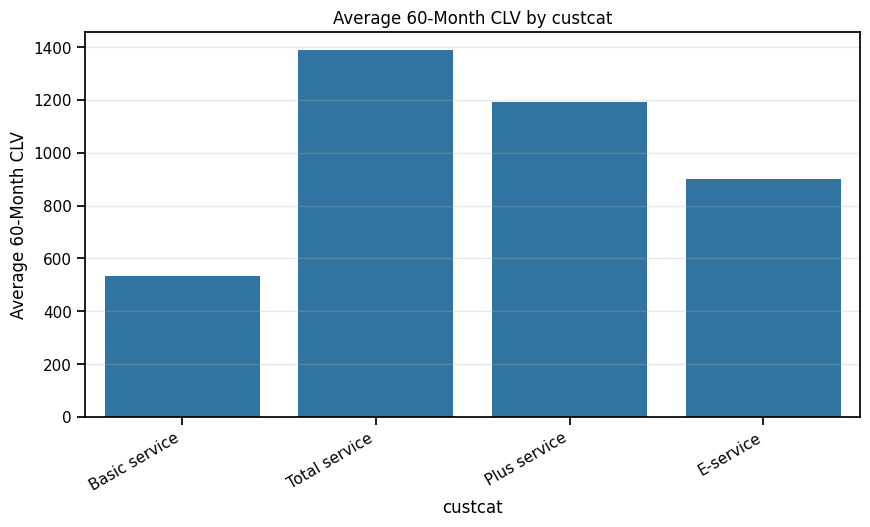

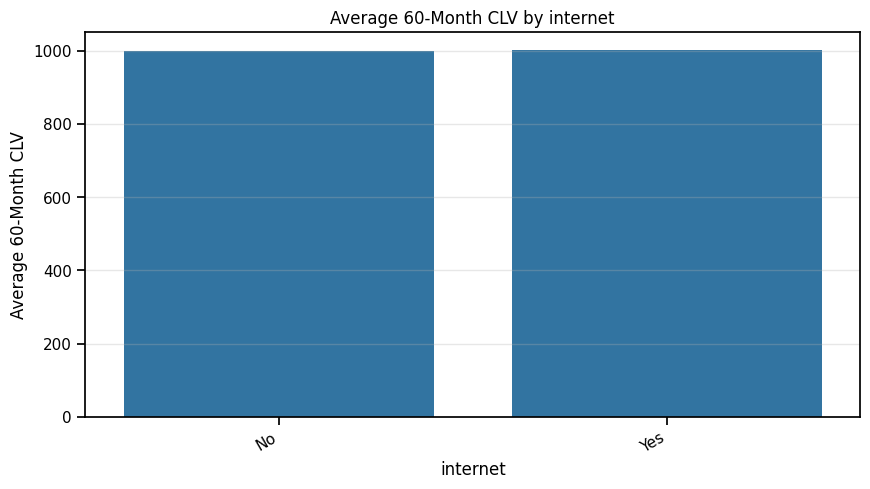

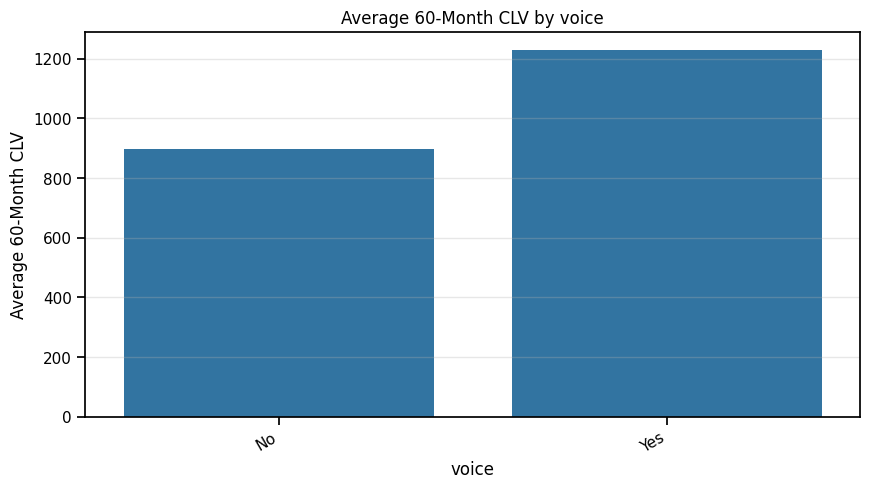

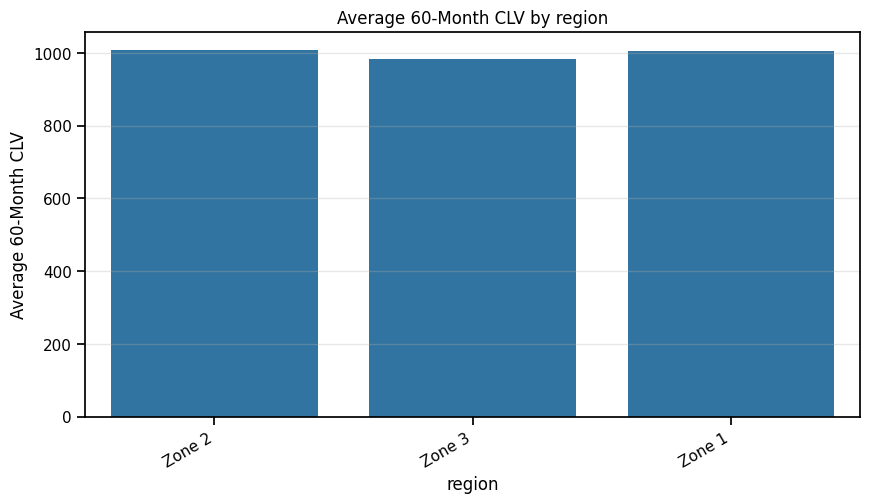

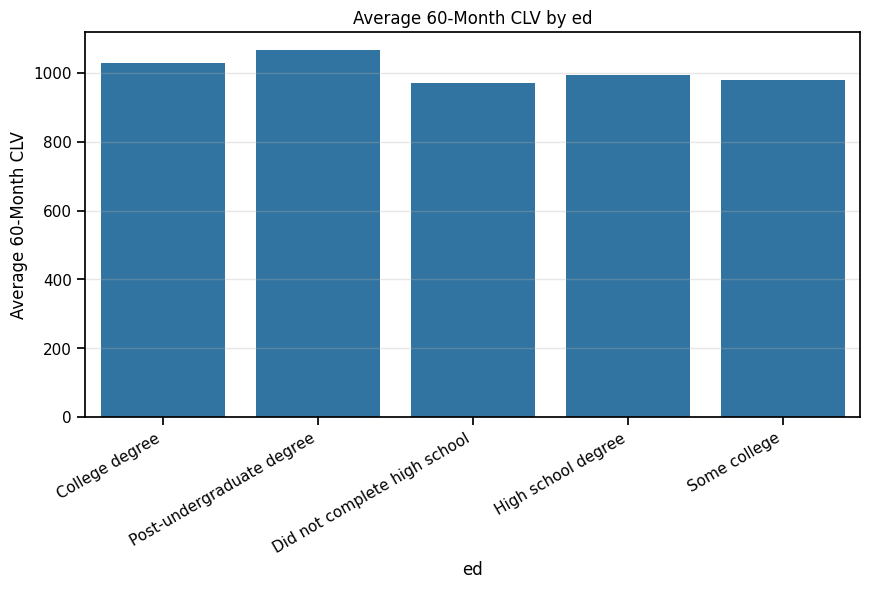

In [18]:
for col in ["custcat", "internet", "voice", "region", "ed"]:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_clv,
        x=col,
        y="CLV_60_months",
        estimator=np.mean,
        errorbar=None
    )
    plt.title(f"Average 60-Month CLV by {col}")
    plt.xlabel(col)
    plt.ylabel("Average 60-Month CLV")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [19]:
clv_threshold = df_clv["CLV_60_months"].median()
risk_threshold = df_clv["churn_risk_12m"].quantile(0.75)

df_clv["valuable_customer"] = df_clv["CLV_60_months"] >= clv_threshold
df_clv["at_risk_customer"] = df_clv["churn_risk_12m"] >= risk_threshold
df_clv["valuable_and_at_risk"] = df_clv["valuable_customer"] & df_clv["at_risk_customer"]

print("CLV threshold:", clv_threshold)
print("12-month churn-risk threshold:", risk_threshold)

print("\nNumber of valuable and at-risk customers:")
print(df_clv["valuable_and_at_risk"].sum())

valuable_at_risk = df_clv[df_clv["valuable_and_at_risk"]].copy()

display(
    valuable_at_risk[[
        "ID", "region", "tenure", "age", "custcat",
        "internet", "voice", "forward",
        "churn_risk_12m", "CLV_12_months", "CLV_60_months"
    ]]
    .sort_values(["churn_risk_12m", "CLV_60_months"], ascending=False)
    .head(20)
)

CLV threshold: 1020.5750860312015
12-month churn-risk threshold: 0.16866183771754975

Number of valuable and at-risk customers:
59


,ID,region,tenure,age,custcat,internet,voice,forward,churn_risk_12m,CLV_12_months,CLV_60_months
139,140,Zone 3,11,32,Total service,Yes,Yes,Yes,0.282069,372.078644,1025.882238
517,518,Zone 1,13,23,Total service,Yes,Yes,Yes,0.275871,373.770608,1038.400010
985,986,Zone 3,24,30,Total service,Yes,Yes,Yes,0.275187,374.069739,1034.480115
663,664,Zone 3,8,35,Total service,Yes,Yes,Yes,0.274051,374.594583,1041.581523
870,871,Zone 1,7,38,Total service,Yes,Yes,No,0.272559,375.178589,1043.814981
207,208,Zone 1,10,27,Total service,Yes,Yes,Yes,0.270434,375.420627,1049.843158
778,779,Zone 1,5,28,Total service,Yes,Yes,Yes,0.269382,376.632526,1047.246913
807,808,Zone 2,29,26,Total service,Yes,Yes,Yes,0.268712,375.953962,1045.698651
518,519,Zone 1,20,35,Total service,Yes,Yes,Yes,0.267699,376.066677,1052.978190
723,724,Zone 3,10,28,Total service,Yes,Yes,Yes,0.264239,377.163687,1062.784163


In [20]:
RETENTION_SPEND_RATE = 0.20

at_risk_population = df_clv[df_clv["at_risk_customer"]].copy()
valuable_at_risk_population = df_clv[df_clv["valuable_and_at_risk"]].copy()

max_budget_all_at_risk = at_risk_population["CLV_12_months"].sum()
recommended_budget_all_at_risk = RETENTION_SPEND_RATE * max_budget_all_at_risk

max_budget_valuable_at_risk = valuable_at_risk_population["CLV_12_months"].sum()
recommended_budget_valuable_at_risk = RETENTION_SPEND_RATE * max_budget_valuable_at_risk

budget_table = pd.DataFrame({
    "Group": [
        "All at-risk customers",
        "Valuable and at-risk customers"
    ],
    "Number of customers": [
        len(at_risk_population),
        len(valuable_at_risk_population)
    ],
    "Total expected 12-month CLV": [
        max_budget_all_at_risk,
        max_budget_valuable_at_risk
    ],
    "Recommended annual retention budget": [
        recommended_budget_all_at_risk,
        recommended_budget_valuable_at_risk
    ]
})

display(budget_table)

,Group,Number of customers,Total expected 12-month CLV,Recommended annual retention budget
0,All at-risk customers,250,61281.293667,12256.258733
1,Valuable and at-risk customers,59,22931.399698,4586.279940


In [21]:
df_clv.to_csv("telco_survival_clv_results.csv", index=False)
comparison_df.to_csv("aft_model_comparison.csv", index=False)
segment_summary.to_csv("segment_clv_summary.csv", index=False)
budget_table.to_csv("retention_budget_summary.csv", index=False)

print("Saved files:")
print("- telco_survival_clv_results.csv")
print("- aft_model_comparison.csv")
print("- segment_clv_summary.csv")
print("- retention_budget_summary.csv")

Saved files:
- telco_survival_clv_results.csv
- aft_model_comparison.csv
- segment_clv_summary.csv
- retention_budget_summary.csv


In [23]:
best_segments = (
    segment_summary
    .sort_values("avg_CLV_60m", ascending=False)
    .head(5)
)

worst_risk_segments = (
    segment_summary
    .sort_values("avg_12m_churn_risk", ascending=False)
    .head(5)
)

coef_for_report = coef_table.copy()
coef_for_report["direction"] = np.where(
    coef_for_report["coef"] > 0,
    "increases expected survival time and lowers churn risk",
    "decreases expected survival time and raises churn risk"
)

top_coef_report = coef_for_report.sort_values("p").head(5)

### Final Report

Based on the model comparison, the Log-Normal AFT model was selected as the final model because it had the lowest AIC among the successfully fitted models. Its concordance was also acceptable, around 0.78, which means the model has a reasonable ability to rank customers by expected survival time. In the final model, age, address, and higher customer service categories increased expected survival time, meaning these customers are less likely to churn quickly. For example, E-service, Plus service, and Total service customers had positive coefficients, so they are expected to stay longer than Basic service customers. On the other hand, internet service, being unmarried, and having voice service had negative coefficients, which means they are linked with shorter survival time and higher churn risk. The strongest warning signal is internet service, since it has a large negative coefficient and a very small p-value.

For customer value, I treated customers with above-median 60-month CLV as valuable, and customers in the top 25% of 12-month churn risk as at-risk. Using this definition, there are 59 valuable and at-risk customers. The most valuable segment is Total service customers, with the highest average 60-month CLV, followed by customers with call forwarding and voice service. Basic service customers are the weakest segment by CLV, even though they also have relatively high churn risk. Assuming this dataset represents the population, the maximum reasonable annual retention budget for all at-risk customers is about 61,281, while a more practical budget using 20% of expected 12-month CLV is about 12,256. For valuable and at-risk customers only, the recommended annual retention budget is about 4,586. I would focus retention actions on these 59 customers first, because losing them would be more expensive than losing low-CLV customers. The company should use targeted offers, service improvements, or loyalty benefits instead of giving the same discount to everyone.